# Task 2: Soprano-Conditioned Harmonization

Train a **2-layer LSTM** that takes **soprano** `(pitch, duration)` tokens as input and predicts **alto, tenor, and bass** at the same rhythmic positions. Run inference on **test-set soprano melodies** (ground truth), combine with predicted lower voices, and export **`symbolic_conditioned.mid`**.

**Setup (same tokenization as Tasks 1–2):**
- Shared vocabulary from training chorales
- 80/10/10 chorale-level split (seed=42)
- Voices aligned by truncating to the shortest voice length per chorale
- Sliding windows of length 32 for training

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from chorale_data import (
    flatten_voice_sequences,
    load_chorales,
    split_chorale_indices,
    PitchDurationVocab,
)
from chorale_harmonization import (
    HarmonizationLSTM,
    align_chorale_voices,
    build_harmonization_dataloaders,
    combine_harmonizations_to_score,
    evaluate_harmonization,
    harmonize_soprano,
    harmonize_test_chorales,
    train_harmonization_with_early_stopping,
)
from chorale_model import export_midi

ROOT = Path(".")
MIDI_PATH = ROOT / "symbolic_conditioned.mid"
CHECKPOINT_PATH = ROOT / "harmonization_best.pt"

MAX_EPOCHS = 100
PATIENCE = 8
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3
WINDOW_SIZE = 32
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Load data and vocabulary

Vocabulary is built from **all training voice sequences** (same as preprocessing notebook), so soprano and lower voices share one token space.

In [2]:
encoded_chorales, metadata = load_chorales()
splits = split_chorale_indices(len(encoded_chorales), seed=SEED)

train_sequences = flatten_voice_sequences(encoded_chorales, splits.train_indices)
vocab = PitchDurationVocab()
vocab.build_from_sequences(train_sequences)

train_loader, val_loader, test_loader = build_harmonization_dataloaders(
    encoded_chorales,
    splits,
    vocab,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
)

print(f"Chorales: {len(encoded_chorales)} (train/val/test = {len(splits.train_indices)}/{len(splits.val_indices)}/{len(splits.test_indices)})")
print(f"Vocabulary size: {len(vocab)}")
print(f"Harmonization windows — train: {len(train_loader.dataset)}, val: {len(val_loader.dataset)}, test: {len(test_loader.dataset)}")

Chorales: 351 (train/val/test = 280/35/36)
Vocabulary size: 323
Harmonization windows — train: 5441, val: 505, test: 515


## Aligned SATB example

Each chorale is truncated to the shortest voice so soprano and ATB tokens share the same index `t`.

In [3]:
sample_idx = splits.train_indices[0]
voices_enc = [vocab.encode(v) for v in encoded_chorales[sample_idx]]
sop, alto, tenor, bass = align_chorale_voices(voices_enc)

print(f"{metadata[sample_idx]['title']} (RK {metadata[sample_idx]['riemenschneider']})")
print(f"Aligned length: {len(sop)} tokens per voice")
print("\nFirst 6 timesteps:")
print(f"  Soprano: {vocab.decode(sop[:6])}")
print(f"  Alto:    {vocab.decode(alto[:6])}")
print(f"  Tenor:   {vocab.decode(tenor[:6])}")
print(f"  Bass:    {vocab.decode(bass[:6])}")

Warum sollt’ ich mich denn grämen (RK 139)
Aligned length: 48 tokens per voice

First 6 timesteps:
  Soprano: [(67, 1.0), (67, 1.0), (69, 1.0), (67, 1.0), (69, 0.5), (71, 0.5)]
  Alto:    [(62, 1.0), (64, 1.0), (62, 1.0), (62, 1.0), (64, 1.0), (65, 1.0)]
  Tenor:   [(59, 1.0), (60, 1.0), (54, 1.0), (55, 1.0), (60, 1.0), (60, 0.5)]
  Bass:    [(55, 1.0), (48, 1.0), (48, 1.0), (47, 1.0), (45, 1.0), (44, 1.0)]


## Model: 2-layer LSTM harmonizer

- **Input:** soprano token window `(batch, 32)`
- **Encoder:** embedding + 2-layer LSTM over soprano
- **Output:** three linear heads predict alto, tenor, and bass tokens at each timestep
- **Loss:** average cross-entropy over the three lower voices

In [4]:
model = HarmonizationLSTM(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=DROPOUT,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {num_params:,}")

HarmonizationLSTM(
  (soprano_embed): Embedding(323, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head_alto): Linear(in_features=256, out_features=323, bias=True)
  (head_tenor): Linear(in_features=256, out_features=323, bias=True)
  (head_bass): Linear(in_features=256, out_features=323, bias=True)
)
Trainable parameters: 1,211,977


## Train with early stopping

Training stops when validation loss does not improve for `PATIENCE` epochs; best weights are restored automatically.

In [5]:
train_losses, val_losses, best_epoch = train_harmonization_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=str(CHECKPOINT_PATH),
)

test_loss = evaluate_harmonization(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}")

Epoch   1  train=4.0008  val=3.7604  *
Epoch   5  train=3.4359  val=3.4442  *
Epoch  10  train=3.2199  val=3.3856  *
Epoch  15  train=2.8885  val=3.4026
Epoch  20  train=2.5457  val=3.4877

Early stopping at epoch 20 (best val=3.3734 at epoch 12)
Loaded best weights from epoch 12 (val=3.3734)
Test loss: 3.3240


## Loss curves

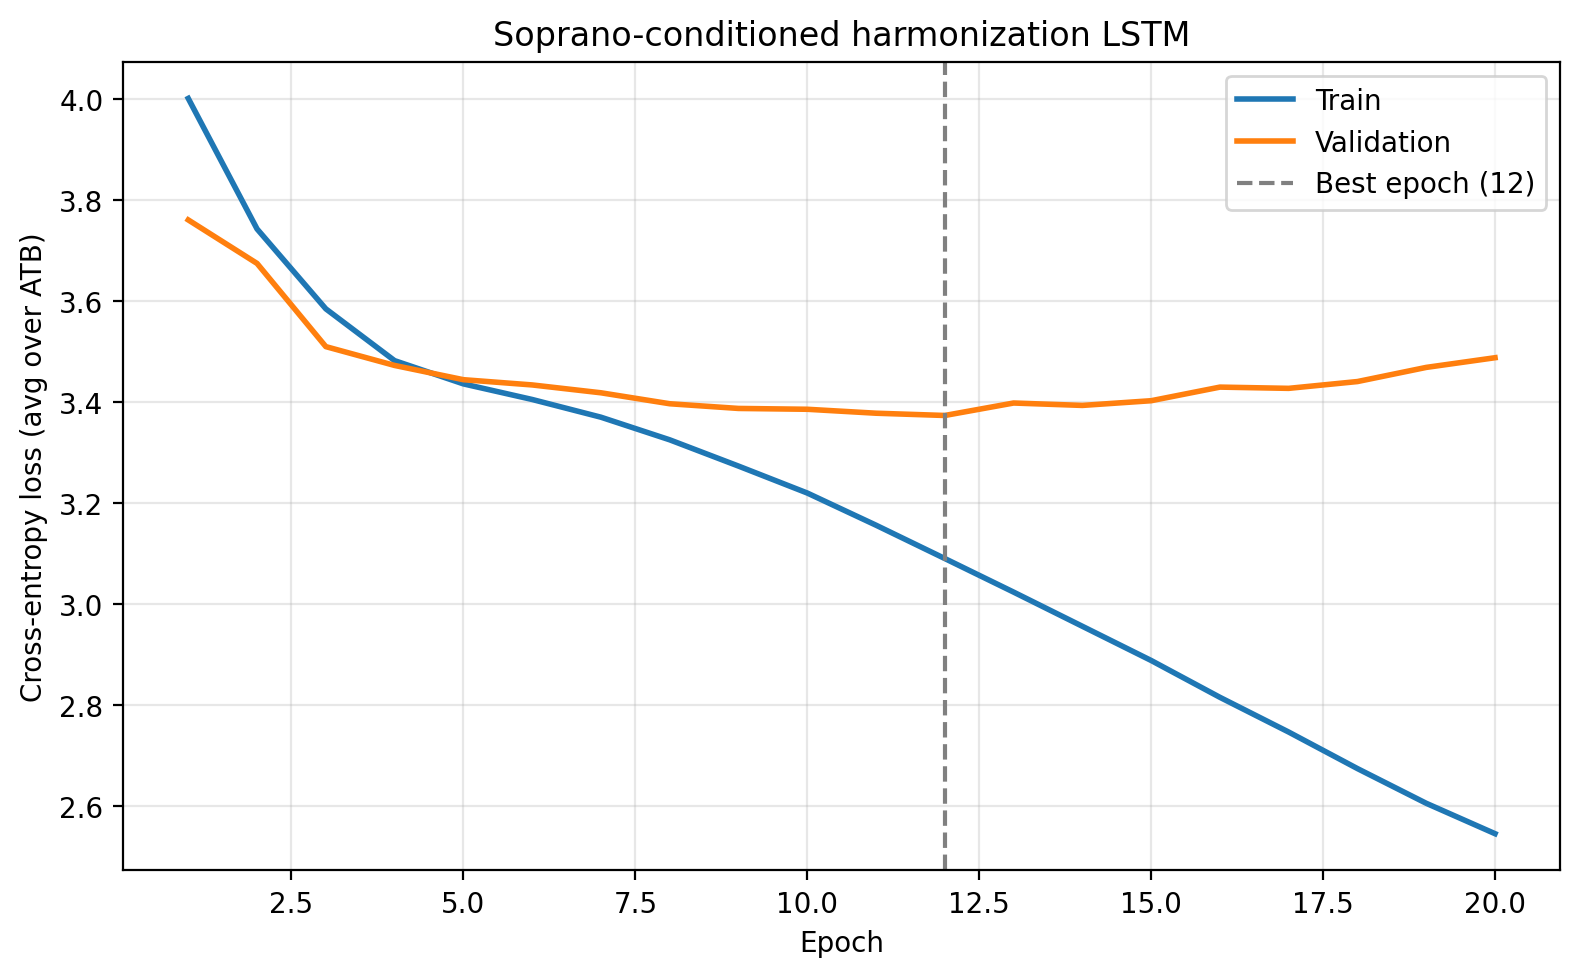

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label="Train", linewidth=2)
ax.plot(epochs, val_losses, label="Validation", linewidth=2)
ax.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss (avg over ATB)")
ax.set_title("Soprano-conditioned harmonization LSTM")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Inference on test-set soprano melodies

For each test chorale we use the **ground-truth soprano** (aligned length) and predict alto, tenor, and bass. The soprano in the exported MIDI is the test melody; lower voices are model-generated.

In [7]:
harmonized_pieces = harmonize_test_chorales(
    model,
    encoded_chorales,
    splits.test_indices,
    vocab,
    metadata,
    device,
)

print(f"Harmonized {len(harmonized_pieces)} test chorales")
label, sop, alto, tenor, bass = harmonized_pieces[0]
print(f"\nExample — {label}, length {len(sop)} tokens")
print(f"  Soprano (input):  {vocab.decode(sop[:6])}")
print(f"  Alto (pred):      {vocab.decode(alto[:6])}")
print(f"  Tenor (pred):     {vocab.decode(tenor[:6])}")
print(f"  Bass (pred):      {vocab.decode(bass[:6])}")

Harmonized 36 test chorales

Example — RK179, length 66 tokens
  Soprano (input):  [(63, 1.0), (67, 1.0), (70, 1.5), (70, 0.5), (70, 1.0), (70, 1.0)]
  Alto (pred):      [(62, 1.0), (62, 1.0), (63, 1.0), (63, 0.5), (63, 1.0), (63, 1.0)]
  Tenor (pred):     [(58, 1.0), (58, 1.0), (58, 1.0), (58, 1.0), (58, 1.0), (58, 1.0)]
  Bass (pred):      [(50, 0.5), (50, 0.5), (48, 0.5), (48, 0.5), (50, 0.5), (51, 1.0)]


## Optional: compare to ground-truth lower voices (evaluation)

Token-level accuracy on the test set — useful for the evaluation section of your presentation.

In [8]:
def voice_accuracy(pred_ids, true_ids):
    correct = sum(p == t for p, t in zip(pred_ids, true_ids))
    return correct / len(true_ids) if true_ids else 0.0

alto_acc, tenor_acc, bass_acc = [], [], []
for idx in splits.test_indices:
    voices = [vocab.encode(v) for v in encoded_chorales[idx]]
    sop, alto_gt, tenor_gt, bass_gt = align_chorale_voices(voices)
    alto_p, tenor_p, bass_p = harmonize_soprano(model, sop, device)
    alto_acc.append(voice_accuracy(alto_p, alto_gt))
    tenor_acc.append(voice_accuracy(tenor_p, tenor_gt))
    bass_acc.append(voice_accuracy(bass_p, bass_gt))

print(f"Test token accuracy (greedy decode):")
print(f"  Alto:  {sum(alto_acc)/len(alto_acc):.3f}")
print(f"  Tenor: {sum(tenor_acc)/len(tenor_acc):.3f}")
print(f"  Bass:  {sum(bass_acc)/len(bass_acc):.3f}")

Test token accuracy (greedy decode):
  Alto:  0.159
  Tenor: 0.136
  Bass:  0.077


## Export `symbolic_conditioned.mid`

All test chorales are written sequentially into one MIDI file (with short gaps between pieces).

In [9]:
score = combine_harmonizations_to_score(harmonized_pieces, vocab)
export_midi(score, str(MIDI_PATH))

torch.save(
    {
        "model_state": model.state_dict(),
        "vocab_size": len(vocab),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "test_loss": test_loss,
        "best_epoch": best_epoch,
    },
    ROOT / "harmonization_lstm.pt",
)

print(f"Saved MIDI: {MIDI_PATH.resolve()}")
print(f"Pieces in file: {len(harmonized_pieces)}")
print(f"Total duration (quarter notes): {score.duration.quarterLength}")

Saved MIDI: /Users/aaronchiuwei/Documents/CSE153/cse153_assignment2/symbolic_conditioned.mid
Pieces in file: 36
Total duration (quarter notes): 88.0


## Summary

- **Task:** symbolic **conditioned** generation — harmonize a given soprano melody.
- **Model:** 2-layer LSTM on soprano → parallel prediction of alto, tenor, bass per timestep.
- **Training:** aligned SATB windows; early stopping on validation loss.
- **Inference:** ground-truth test sopranos + predicted lower voices → **`symbolic_conditioned.mid`**.

**Limitation to mention in your presentation:** voices are aligned by truncating to the shortest part, which does not capture all polyphonic detail in Bach chorales; a beat-synchronous or chord-level alignment would be more musically faithful.